# Viability- and feedback-oriented sustainability model in Julia

This notebook mirrors the Python notebook while keeping the time-scale mismatch explicit:

$$
\tau_R \frac{dR}{dt} = G(R) - D(R) + E,
\qquad
\tau_I \frac{dI}{dt} = c\,u - I,
\qquad
\varepsilon = \frac{\tau_I}{\tau_R}.
$$

- `\tau_R`: regeneration or system-adjustment time scale
- `\tau_I`: implementation time scale
- `\varepsilon`: governance-to-system time-scale ratio

The worked example compares open-loop governance with state-feedback governance.

If this notebook is opened in Jupyter and the Julia kernel is not available yet, install it once with `import Pkg; Pkg.add("IJulia")` in Julia.

In [1]:
import Pkg

try
    using Plots
catch
    Pkg.add("Plots")
    using Plots
end

ROOT = normpath(joinpath(pwd(), ".."))
IMG = joinpath(ROOT, "images")
mkpath(IMG)

default(
    background_color=:white,
    foreground_color_subplot=RGB(0.07, 0.09, 0.16),
    guidefontsize=13,
    tickfontsize=10,
    legendfontsize=9,
    titlefontsize=12,
    size=(1200, 820),
    dpi=220,
)

function save_figure(p, filename)
    image_path = joinpath(IMG, filename)
    savefig(p, image_path)
    println("saved " * image_path)
end

save_figure (generic function with 1 method)

In [2]:
function rk4(f, y0::AbstractVector, t::AbstractVector)
    y = zeros(length(t), length(y0))
    y[1, :] .= y0
    for i in 1:length(t)-1
        h = t[i + 1] - t[i]
        yi = vec(y[i, :])
        k1 = f(t[i], yi)
        k2 = f(t[i] + 0.5 * h, yi .+ 0.5 * h .* k1)
        k3 = f(t[i] + 0.5 * h, yi .+ 0.5 * h .* k2)
        k4 = f(t[i] + h, yi .+ h .* k3)
        y[i + 1, :] .= yi .+ h .* (k1 .+ 2 .* k2 .+ 2 .* k3 .+ k4) ./ 6
    end
    return y
end

logistic_regeneration(r; rho=0.7, capacity=1.0) = rho * r * (1 - r / capacity)

function clipped_linear_policy(r; target=0.65, gain=2.2, base=0.15, u_max=1.0)
    shortfall = max(target - r, 0.0)
    return clamp(base + gain * shortfall, 0.0, u_max)
end

Base.@kwdef struct SustainabilityModel
    tau_R::Float64 = 4.0
    regen_rate::Float64 = 0.7
    capacity::Float64 = 1.0
    demand_pressure::Float64 = 0.38
    overload_sensitivity::Float64 = 0.85
    intervention_strength::Float64 = 0.9
    compliance::Float64 = 0.78
    tau_I::Float64 = 5.0
    viable_min::Float64 = 0.3
    target::Float64 = 0.65
    control_gain::Float64 = 2.2
    base_effort::Float64 = 0.15
    u_max::Float64 = 1.0
end

epsilon(model::SustainabilityModel) = model.tau_I / model.tau_R

G(model::SustainabilityModel, r) = logistic_regeneration(r; rho=model.regen_rate, capacity=model.capacity)

function D(model::SustainabilityModel, r, i, u, t)
    stress = max(model.target - r, 0.0)
    return model.demand_pressure * r + model.overload_sensitivity * stress * r
end

function policy(model::SustainabilityModel, r, i, t; mode=:feedback)
    if mode == :open_loop
        return model.base_effort
    end
    return clipped_linear_policy(
        r;
        target=model.target,
        gain=model.control_gain,
        base=model.base_effort,
        u_max=model.u_max,
    )
end

function E(model::SustainabilityModel, r, i, u, t)
    return model.intervention_strength * i * (1 - r / model.capacity)
end

function rhs(model::SustainabilityModel, t, y; mode=:feedback)
    r = clamp(y[1], 0.0, model.capacity)
    i = max(y[2], 0.0)
    u = policy(model, r, i, t; mode=mode)
    g = G(model, r)
    d = D(model, r, i, u, t)
    e = E(model, r, i, u, t)
    dr = (g - d + e) / model.tau_R
    di = (model.compliance * u - i) / model.tau_I
    return [dr, di]
end

function simulate(model::SustainabilityModel, t::AbstractVector, y0::AbstractVector; mode=:feedback)
    states = rk4((tt, yy) -> rhs(model, tt, yy; mode=mode), y0, t)
    resource = clamp.(states[:, 1], 0.0, model.capacity)
    impact = max.(states[:, 2], 0.0)
    decision = [policy(model, r, i, tt; mode=mode) for (tt, r, i) in zip(t, resource, impact)]
    regen = [G(model, r) for r in resource]
    deplete = [D(model, r, i, u, tt) for (tt, r, i, u) in zip(t, resource, impact, decision)]
    support = [E(model, r, i, u, tt) for (tt, r, i, u) in zip(t, resource, impact, decision)]
    viable = resource .>= model.viable_min
    return (
        t=t,
        R=resource,
        I=impact,
        u=decision,
        G=regen,
        D=deplete,
        E=support,
        viable=viable,
    )
end

function summarize_run(name, result, model)
    violations = findall(.!result.viable)
    if isempty(violations)
        status = "viable for the full horizon"
    else
        status = "leaves viability at t=$(round(result.t[first(violations)], digits=2))"
    end
    println(
        "$(name): R_min=$(round(minimum(result.R), digits=3)), " *
        "R_final=$(round(last(result.R), digits=3)), " *
        "I_final=$(round(last(result.I), digits=3)), $(status)"
    )
end

summarize_run (generic function with 1 method)

In [3]:
model = SustainabilityModel(
    tau_R=4.0,
    regen_rate=0.72,
    demand_pressure=0.43,
    overload_sensitivity=1.10,
    intervention_strength=1.05,
    compliance=0.78,
    tau_I=6.0,
    viable_min=0.30,
    target=0.68,
    control_gain=2.8,
    base_effort=0.08,
    u_max=1.00,
)

t = collect(range(0.0, 40.0; length=801))
y0 = [0.72, 0.02]

open_loop = simulate(model, t, y0; mode=:open_loop)
feedback = simulate(model, t, y0; mode=:feedback)

println("tau_R=$(model.tau_R), tau_I=$(model.tau_I), epsilon=$(round(epsilon(model), digits=2))")
summarize_run("open_loop", open_loop, model)
summarize_run("feedback", feedback, model)

tau_R=4.0, tau_I=6.0, epsilon=1.5
open_loop: R_min=0.155, R_final=0.155, I_final=0.062, leaves viability at t=16.8
feedback: R_min=0.518, R_final=0.568, I_final=0.303, viable for the full horizon


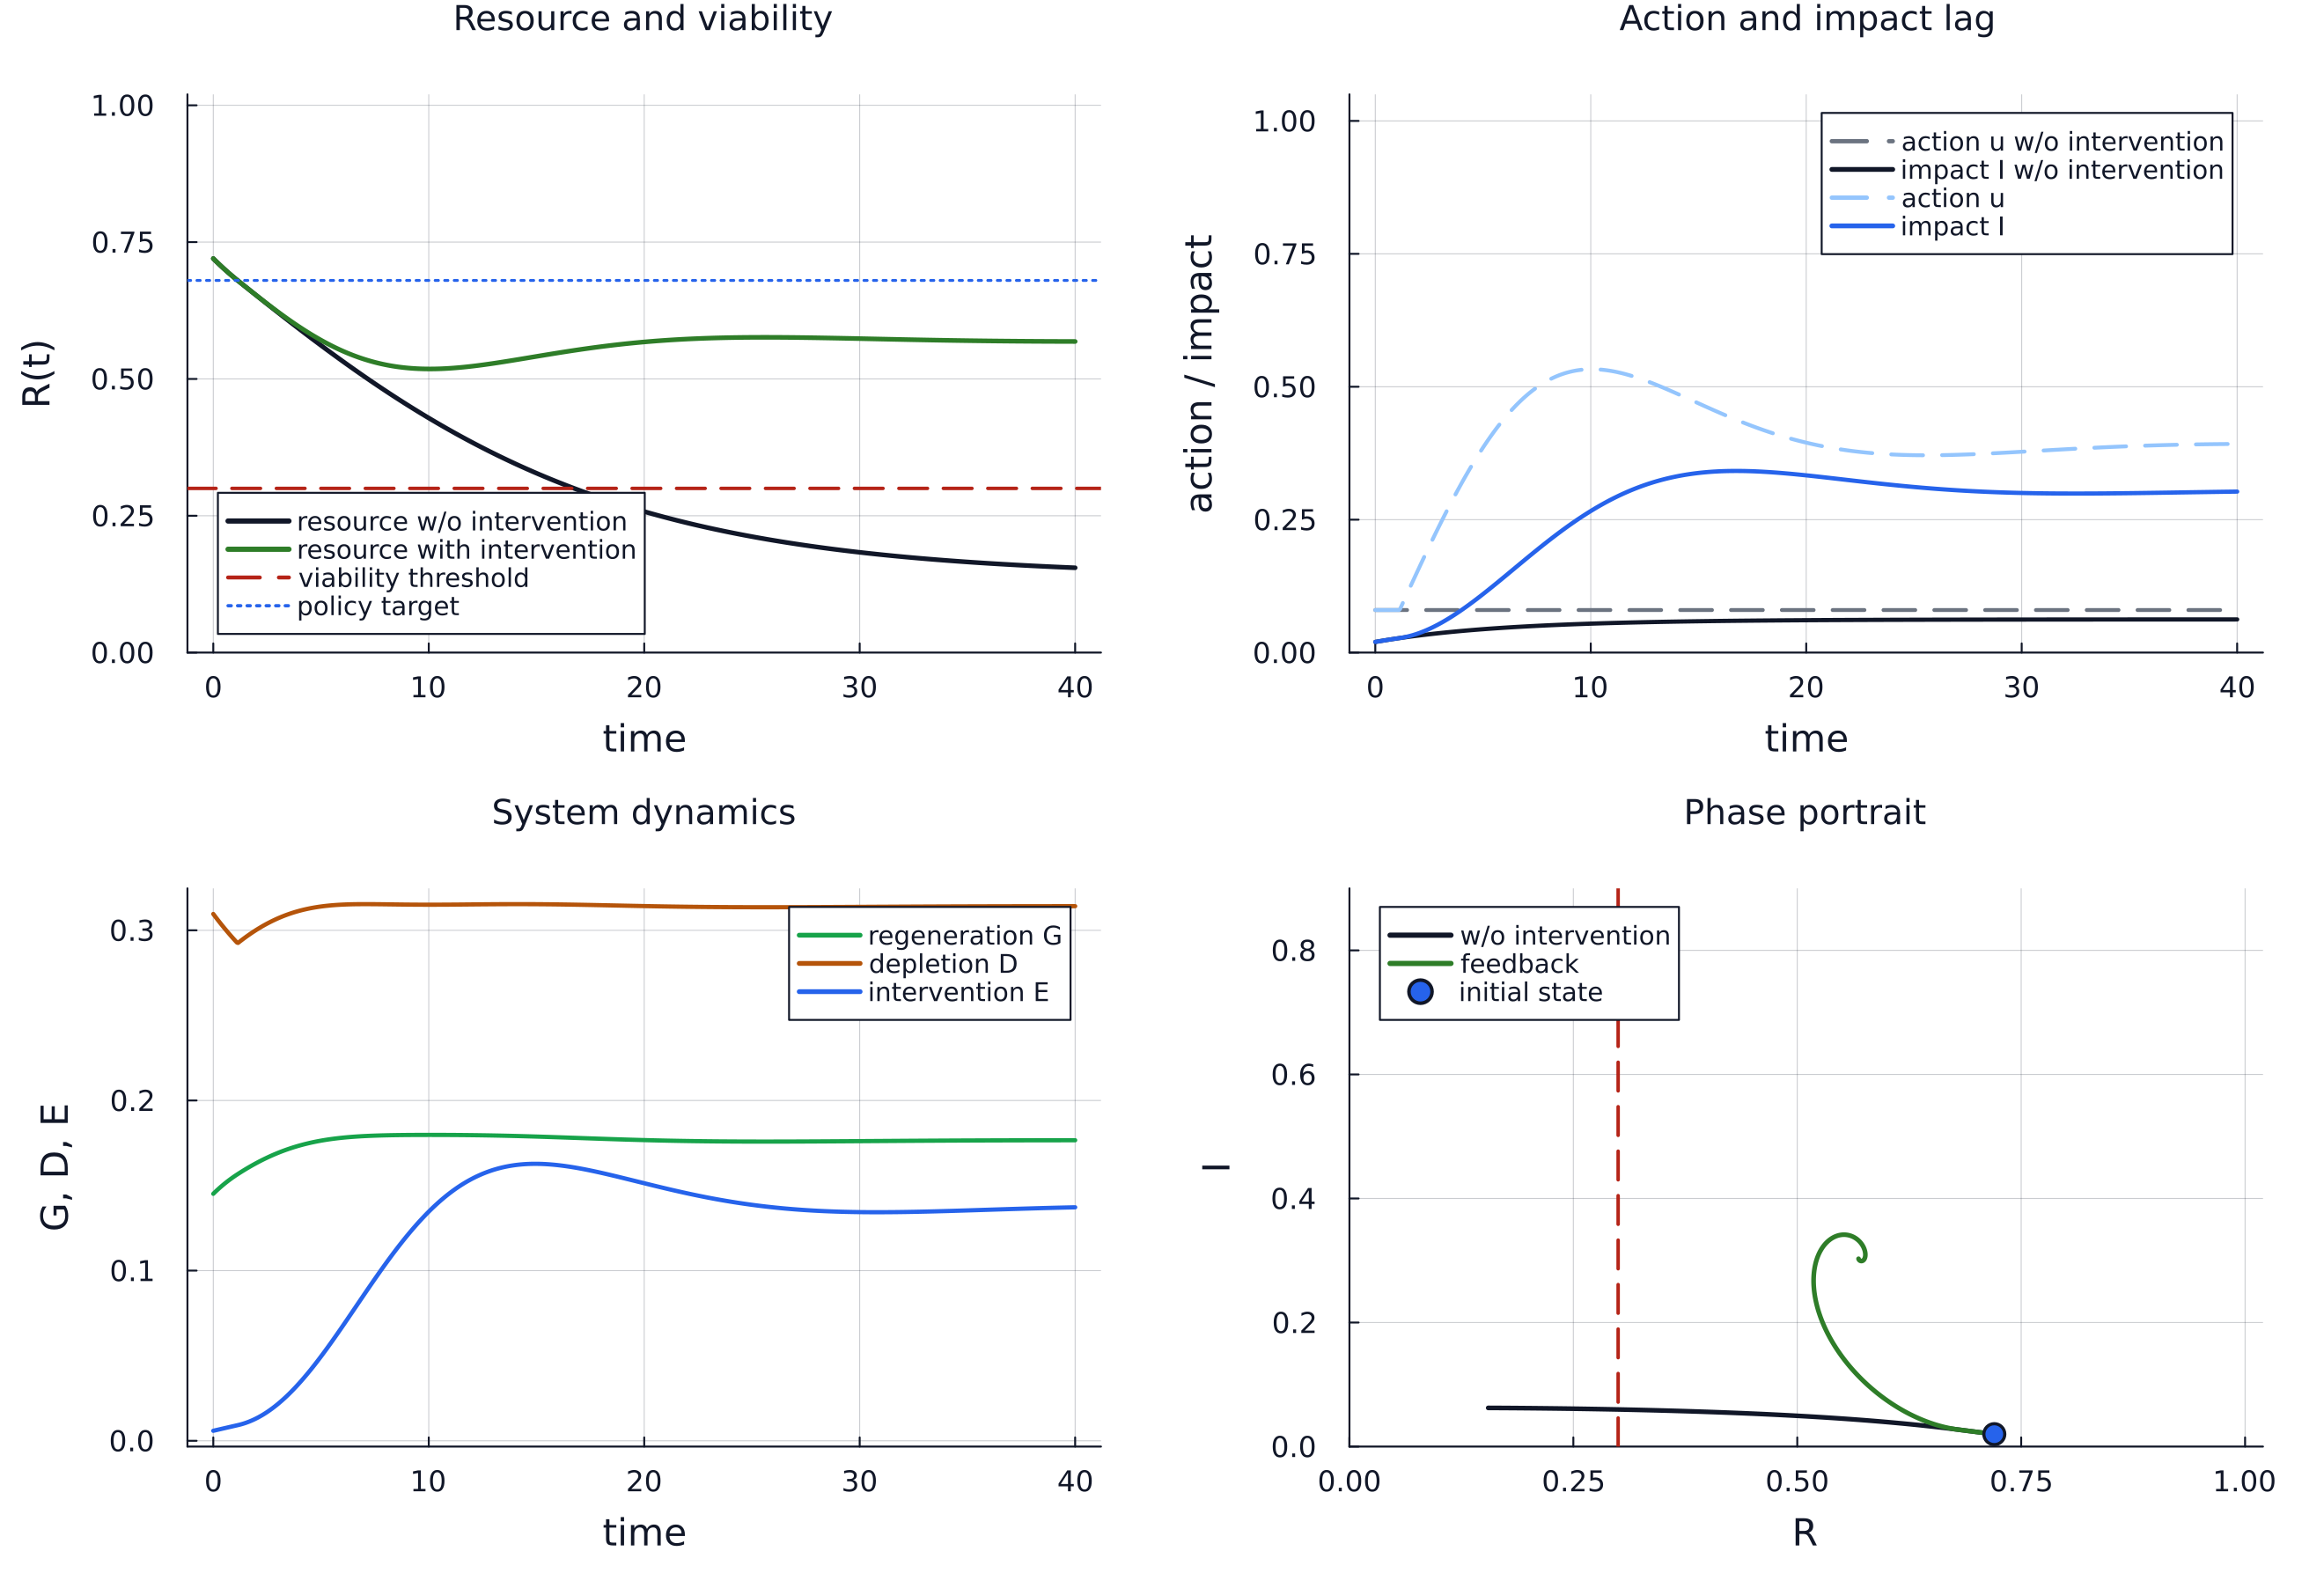

In [10]:
# Resource and viability
p1 = plot(
    t,
    open_loop.R;
    color=RGB(0.07, 0.09, 0.16),
    linewidth=2.4,
    label="resource w/o intervention",
    title="Resource and viability",
    xlabel="time",
    ylabel="R(t)",
    legend=:bottomleft,
    ylims=(0.0, 1.02),
    gridalpha=0.22,
)
plot!(p1, t, feedback.R; color=RGB(0.18, 0.49, 0.16), linewidth=2.4, label="resource with intervention")
hline!(p1, [model.viable_min]; color=RGB(0.71, 0.14, 0.09), linestyle=:dash, linewidth=1.8, label="viability threshold")
hline!(p1, [model.target]; color=RGB(0.15, 0.39, 0.92), linestyle=:dot, linewidth=1.5, label="policy target")

# Governance lag
p2 = plot(
    t,
    open_loop.u;
    color=RGB(0.42, 0.45, 0.50),
    linewidth=2.0,
    linestyle=:dash,
    label="action u w/o intervention",
    title="Action and impact lag",
    xlabel="time",
    ylabel="action / impact",
    legend=:topright,
    ylims=(0.0, 1.05),
    gridalpha=0.22,
)
plot!(p2, t, open_loop.I; color=RGB(0.07, 0.09, 0.16), linewidth=2.2, label="impact I w/o intervention")
plot!(p2, t, feedback.u; color=RGB(0.58, 0.77, 0.99), linewidth=2.0, linestyle=:dash, label="action u")
plot!(p2, t, feedback.I; color=RGB(0.15, 0.39, 0.92), linewidth=2.2, label="impact I")

# Flow balance
p3 = plot(
    t,
    feedback.G;
    color=RGB(0.09, 0.64, 0.29),
    linewidth=2.2,
    label="regeneration G",
    title="System dynamics",
    xlabel="time",
    ylabel="G, D, E",
    legend=:topright,
    gridalpha=0.22,
)
plot!(p3, t, feedback.D; color=RGB(0.71, 0.33, 0.04), linewidth=2.2, label="depletion D")
plot!(p3, t, feedback.E; color=RGB(0.15, 0.39, 0.92), linewidth=2.2, label="intervention E")
# plot!(p3, t, feedback.G .- feedback.D .+ feedback.E; color=RGB(0.07, 0.09, 0.16), linewidth=2.4, label="net dR/dt")

# Phase portrait
p4 = plot(
    open_loop.R,
    open_loop.I;
    color=RGB(0.07, 0.09, 0.16),
    linewidth=2.4,
    label="w/o intervention",
    title="Phase portrait",
    xlabel="R",
    ylabel="I",
    legend=:topleft,
    xlims=(0.0, 1.02),
    ylims=(0.0, 0.9),
    gridalpha=0.22,
)
plot!(p4, feedback.R, feedback.I; color=RGB(0.18, 0.49, 0.16), linewidth=2.4, label="feedback")
scatter!(p4, [y0[1]], [y0[2]]; color=RGB(0.15, 0.39, 0.92), markersize=6, label="initial state")
vline!(p4, [model.viable_min]; color=RGB(0.71, 0.14, 0.09), linestyle=:dash, linewidth=1.8, label="")

plt = plot(p1, p2, p3, p4; layout=(2, 2), size=(1200, 820), margin=6Plots.mm)
#save_figure(plt, "viability_feedback_solver_julia.png")
#plt

In [ ]:
# Sensitivity analysis for the governance-to-system timescale ratio epsilon = tau_I / tau_R
tau_ratios = [0.5, 1.0, 1.5, 2.0, 3.0]
ratio_colors = [
    RGB(0.27, 0.21, 0.56),
    RGB(0.19, 0.41, 0.56),
    RGB(0.13, 0.57, 0.55),
    RGB(0.37, 0.73, 0.38),
    RGB(0.99, 0.91, 0.14),
]

sensitivity_runs = [
    let ratio = ratio
        ratio_model = SustainabilityModel(
            tau_R=model.tau_R,
            regen_rate=model.regen_rate,
            capacity=model.capacity,
            demand_pressure=model.demand_pressure,
            overload_sensitivity=model.overload_sensitivity,
            intervention_strength=model.intervention_strength,
            compliance=model.compliance,
            tau_I=ratio * model.tau_R,
            viable_min=model.viable_min,
            target=model.target,
            control_gain=model.control_gain,
            base_effort=model.base_effort,
            u_max=model.u_max,
        )
        (
            ratio=ratio,
            model=ratio_model,
            result=simulate(ratio_model, t, y0; mode=:feedback),
        )
    end
    for ratio in tau_ratios
]

p_ratio_R = plot(
    title="Resource and viability sensitivity",
    xlabel="time",
    ylabel="R(t)",
    legend=:bottomleft,
    ylims=(0.0, 1.02),
    gridalpha=0.22,
)
hline!(p_ratio_R, [model.viable_min]; color=RGB(0.71, 0.14, 0.09), linestyle=:dash, linewidth=1.8, label="viability threshold")
hline!(p_ratio_R, [model.target]; color=RGB(0.15, 0.39, 0.92), linestyle=:dot, linewidth=1.5, label="policy target")
for (idx, run) in enumerate(sensitivity_runs)
    plot!(
        p_ratio_R,
        t,
        run.result.R;
        color=ratio_colors[idx],
        linewidth=2.4,
        label="feedback, ratio=$(run.ratio)",
    )
end

p_ratio_I = plot(
    title="Impact lag sensitivity",
    xlabel="time",
    ylabel="I(t)",
    legend=:topright,
    ylims=(0.0, 0.9),
    gridalpha=0.22,
)
for (idx, run) in enumerate(sensitivity_runs)
    plot!(
        p_ratio_I,
        t,
        run.result.I;
        color=ratio_colors[idx],
        linewidth=2.4,
        label="feedback, ratio=$(run.ratio)",
    )
end

p_ratio_E = plot(
    title="Intervention sensitivity",
    xlabel="time",
    ylabel="E(t)",
    legend=:topright,
    gridalpha=0.22,
)
for (idx, run) in enumerate(sensitivity_runs)
    plot!(
        p_ratio_E,
        t,
        run.result.E;
        color=ratio_colors[idx],
        linewidth=2.4,
        label="feedback, ratio=$(run.ratio)",
    )
end

p_ratio_phase = plot(
    title="Phase portrait sensitivity",
    xlabel="R",
    ylabel="I",
    legend=:topleft,
    xlims=(0.0, 1.02),
    ylims=(0.0, 0.9),
    gridalpha=0.22,
)
vline!(p_ratio_phase, [model.viable_min]; color=RGB(0.71, 0.14, 0.09), linestyle=:dash, linewidth=1.8, label="viability threshold")
for (idx, run) in enumerate(sensitivity_runs)
    plot!(
        p_ratio_phase,
        run.result.R,
        run.result.I;
        color=ratio_colors[idx],
        linewidth=2.4,
        label="feedback, ratio=$(run.ratio)",
    )
end
scatter!(p_ratio_phase, [y0[1]], [y0[2]]; color=RGB(0.15, 0.39, 0.92), markersize=6, label="initial state")

ratio_plt = plot(p_ratio_R, p_ratio_I, p_ratio_E, p_ratio_phase; layout=(2, 2), size=(1200, 820), margin=6Plots.mm)
# save_figure(ratio_plt, "viability_feedback_ratio_sensitivity_julia.png")
ratio_plt
